In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

In [2]:
df = pd.read_csv("df_assignment.csv")

crimes = [
    "assault",
    "robbery",
    "vandalism",
    "motor vehicle theft",
]

In [3]:
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"]).copy()

df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour  # 0..167

df_focus = df[df["category"].isin(crimes)].copy()

## Assignment 1.5: Regression and Correlation

### Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync? Choose 4 crimes and create a Scatterplot and Linear Regression.

In [4]:
hours = pd.Index(range(168), name="hour_of_week")

weekly_counts = (
    df_focus.groupby(["category", "hour_of_week"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=crimes)
    .reindex(columns=hours, fill_value=0)
)

In [ ]:
def fit_line_closed_form(x, y):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)

    x_mean = x.mean()
    y_mean = y.mean()

    num = (x * y).sum() - N * x_mean * y_mean
    den = (x * x).sum() - N * (x_mean ** 2)

    if den == 0:
        a = 0.0
        b = y_mean
    else:
        a = num / den
        b = y_mean - a * x_mean

    return a, b

def r2_manual(x, y, a, b):
    
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    y_hat = a * x + b
    ss_res = ((y - y_hat) ** 2).sum()
    ss_tot = ((y - y.mean()) ** 2).sum()

    if ss_tot == 0:
        return 0.0

    return 1 - (ss_res / ss_tot)

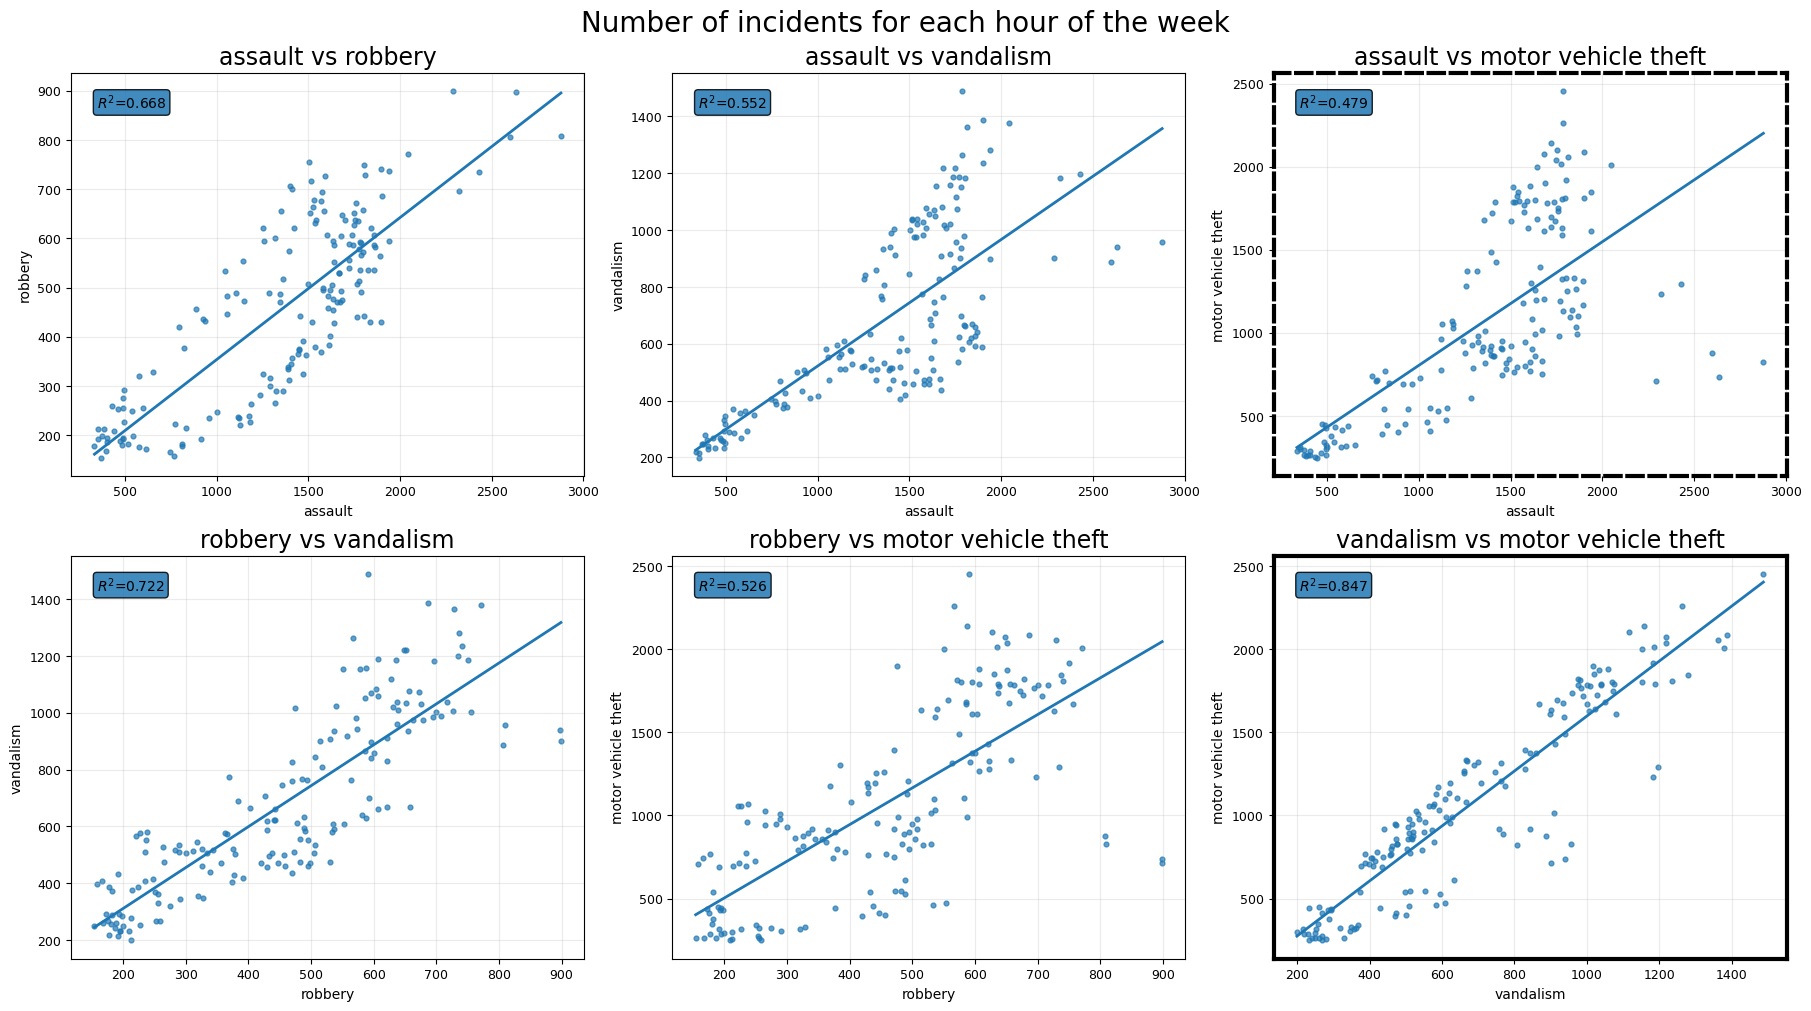

In [8]:
pairs = list(combinations(crimes, 2))
m = len(pairs)

ncols = 3
nrows = math.ceil(m / ncols)

results = {}
for c1, c2 in pairs:
    x = weekly_counts.loc[c1].values.astype(float)
    y = weekly_counts.loc[c2].values.astype(float)

    a, b = fit_line_closed_form(x, y)
    r2 = r2_manual(x, y, a, b)

    results[(c1, c2)] = (a, b, r2)

best_pair = max(results, key=lambda k: results[k][2])
worst_pair = min(results, key=lambda k: results[k][2])

fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for idx, (c1, c2) in enumerate(pairs):
    ax = axes[idx]

    x = weekly_counts.loc[c1].values.astype(float)
    y = weekly_counts.loc[c2].values.astype(float)

    a, b, r2 = results[(c1, c2)]

    ax.scatter(x, y, s=12, alpha=0.7)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, a*xs + b, linewidth=2)

    ax.set_title(f"{c1} vs {c2}", fontsize=17)
    ax.set_xlabel(c1, fontsize=10)
    ax.set_ylabel(c2, fontsize=10)

    ax.text(0.05, 0.95, f"$R^2$={r2:.3f}",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=10, bbox=dict(boxstyle="round,pad=0.25", alpha=0.85))

    ax.grid(True, alpha=0.25)
    ax.tick_params(labelsize=9)

    #Highlight the best/worst
    if (c1, c2) == best_pair:
        for spine in ax.spines.values():
            spine.set_linewidth(3)

    if (c1, c2) == worst_pair:
        for spine in ax.spines.values():
            spine.set_linewidth(3)
            spine.set_linestyle("--")

for k in range(m, len(axes)):
    axes[k].axis("off")

plt.suptitle("Number of incidents for each hour of the week", fontsize=20)
plt.show()

From the scatterplot matrix and the computed $R^2$ values, the most correlated pair of crimes is vandalism and motor vehicle theft, with an $R^2$ = 0.847. This means there is a strong linear relationship for incidents between the these two crimes throughout the week. The points in the scatterplot are close to the regression line which means the two crimes have a similar weekly rhythm.

The least correlated pair is assault and motor vehicle theft, with an $R^2$ = 0.479. While there is still a positive relationship between them, there is heavy scatter around the regression line, indicating that their patterns throughout the week are less similar.

This makes sense because crimes like vandalism and motor vehicle theft have similarities in how they take place, such as occuring during nighttime hours or periods when fewer people are around. In contrast, assault is closer related to social interactions and crowded environments, which leads to a different weekly rhythm.